In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("cleaned_apartment_data.csv", low_memory=False)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99493 entries, 0 to 99492
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   category       99493 non-null  object 
 1   title          99493 non-null  object 
 2   body           99493 non-null  object 
 3   amenities      99493 non-null  object 
 4   bathrooms      99493 non-null  float64
 5   bedrooms       99493 non-null  float64
 6   currency       99493 non-null  object 
 7   fee            99493 non-null  object 
 8   has_photo      99493 non-null  object 
 9   pets_allowed   99493 non-null  object 
 10  price          99493 non-null  float64
 11  price_display  99493 non-null  float64
 12  price_type     99493 non-null  object 
 13  square_feet    99493 non-null  float64
 14  address        7865 non-null   object 
 15  cityname       99220 non-null  object 
 16  state          99493 non-null  object 
 17  latitude       99493 non-null  float64
 18  longit

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,housing/rent/apartment,one br 507 & 509 esplanade,"this unit is located at 507 & 509 esplanade, r...",none,1.0,1.0,USD,No,Thumbnail,cats,...,2195.0,Monthly,542.0,507 509 Esplanade,Redondo Beach,ca,33.8520,-118.3759,RentLingo,1.577360e+09
1,housing/rent/apartment,three br 146 lochview drive,"this unit is located at 146 lochview drive, ne...",none,1.5,3.0,USD,No,Thumbnail,"cats,dogs",...,1250.0,Monthly,1500.0,146 Lochview Dr,Newport News,va,37.0867,-76.4941,RentLingo,1.577360e+09
2,housing/rent/apartment,three br 3101 morningside drive,this unit is located at 3101 morningside drive...,none,2.0,3.0,USD,No,Thumbnail,none,...,1395.0,Monthly,1650.0,3101 Morningside Dr,Raleigh,nc,35.8230,-78.6438,RentLingo,1.577360e+09
3,housing/rent/apartment,two br 209 aegean way,"this unit is located at 209 aegean way, vacavi...",none,1.0,2.0,USD,No,Thumbnail,"cats,dogs",...,1600.0,Monthly,820.0,209 Aegean Way,Vacaville,ca,38.3622,-121.9712,RentLingo,1.577360e+09
4,housing/rent/apartment,one br 4805 marquette ne,"this unit is located at 4805 marquette ne, alb...",none,1.0,1.0,USD,No,Thumbnail,"cats,dogs",...,975.0,Monthly,624.0,4805 Marquette NE,Albuquerque,nm,35.1038,-106.6110,RentLingo,1.577360e+09


In [24]:
# Price bin categories
bins = [0, 1000, 2000, float("inf")]
labels = ["Low", "Medium", "High"]

df["price_category"] = pd.cut(df["price"], bins=bins, labels=labels, right=True)

# Counts
df["price_category"].value_counts()

# Percentages
df["price_category"].value_counts(normalize=True).mul(100).round(2)

price_category
Medium    57.87
Low       24.32
High      17.81
Name: proportion, dtype: float64

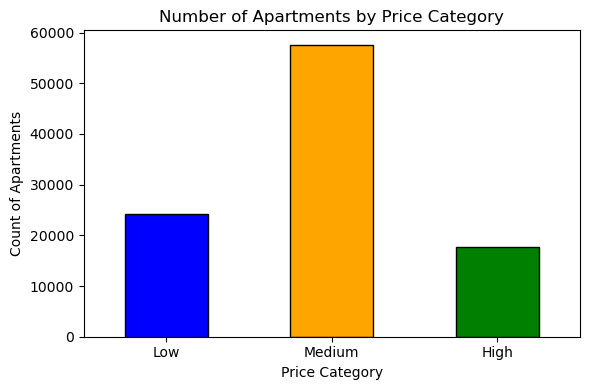

In [12]:
# Bar chart number of apartments by price

counts = df["price_category"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color=["blue", "orange", "green"], edgecolor="black")

plt.title("Number of Apartments by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Count of Apartments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

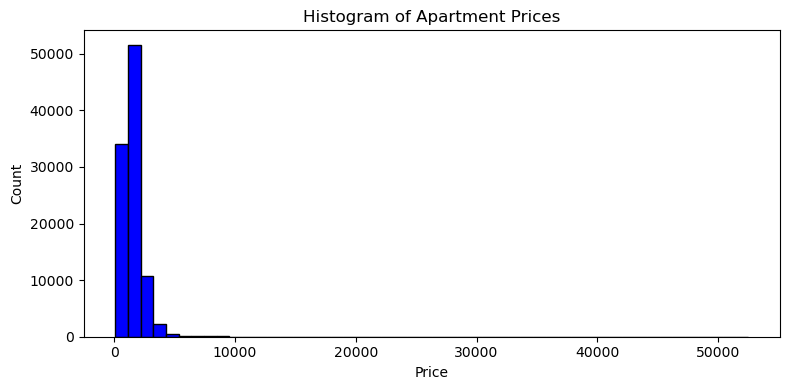

In [15]:
# Histogram of Apartment Prices

plt.figure(figsize=(8, 4))
plt.hist(df["price"], bins=50, edgecolor="black", color="blue")
plt.title("Histogram of Apartment Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

We created a new target variable called price_category by grouping apartment prices into Low, Medium, and High ranges with simple bar and histogram chart showing rent prices.

#Planned features

Target:

    price_category (Low, Medium, High).

Numeric features (in progess):

    square_feet: Apartment size in square feet.
    bedrooms: Number of bedrooms.
    bathrooms: Number of bathrooms.
    latitude, longitude: Location coordinates.

Categorical features (in progress):

    cityname: City of the listing.
    state: State abbreviation.
    pets_allowed: Whether pets are allowed.
    has_photo: Whether the listing has a photo.
    fee: Whether there is an extra fee.
    currency, price_type: Currency and price type.